#Phase A-0: 数据探索 — 从真实 ID 数组推导用户偏好画像
#目标
#解析hybrid_user_profile中每个用户的 purchase/assets/works/prompt/commerceID 数组，
#回查content_features +published_*表，构建每用户的真实偏好分布。
#输入
#hybrid_user_profile.csv(6,006 用户)
#content_features.csv (39,001 条)
#published_asset.csv / published_prompt.csv / published_commerce.csv
#输出
#每用户 content_type 分布
#每用户 theme 分布
#每用户 quality 分布 (purchase_rate, like_rate 等加权)
#每用户 price_tier 分布
#偏好画像矩阵: 6,006 × N

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import json
import ast

plt.rcParams['font.family'] = ['SimHei', 'Microsoft YaHei', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

DATA_SRC = 'D:/dev/projects/zhere_olap/data/recommendation'
print('Setup OK')

Setup OK


In [2]:
# 1. 加载全部原始表
users = pd.read_csv(f'{DATA_SRC}/hybrid_user_profile.csv', encoding='utf-8-sig')
content_features = pd.read_csv(f'{DATA_SRC}/content_features.csv', encoding='utf-8-sig')
asset = pd.read_csv(f'{DATA_SRC}/published_asset.csv', encoding='utf-8-sig')
prompt = pd.read_csv(f'{DATA_SRC}/published_prompt.csv', encoding='utf-8-sig')
commerce = pd.read_csv(f'{DATA_SRC}/published_commerce.csv', encoding='utf-8-sig')

print(f'Users:              {len(users):>8,}')
print(f'Content features:   {len(content_features):>8,}')
print(f'Published asset:    {len(asset):>8,}')
print(f'Published prompt:   {len(prompt):>8,}')
print(f'Published commerce: {len(commerce):>8,}')

Users:                 6,006
Content features:     39,000
Published asset:      15,000
Published prompt:     12,000
Published commerce:   12,000


In [3]:
# 2. 检查 ID 数组字段的格式
id_array_cols = ['purchase', 'assets', 'works', 'prompt', 'commerce']
sample = users.iloc[0]
for col in id_array_cols:
    val = sample[col]
    print(f'{col}: type={type(val).__name__}, len={len(str(val))}, preview={str(val)[:120]}')

purchase: type=str, len=75, preview=[34c9ad74-13bc-4870-a018-b2eef3e8cf83,8254d5ec-872f-4384-af38-8cb7308f0f0b]
assets: type=str, len=149, preview=[9795b9fd-71a5-486f-bf3c-9645ab3cd5b7,336c4d65-2e2e-46ed-8c2e-8b8c6bd12ac7,8b476e37-45df-4a75-8961-be14dbd7f0c5,afefedde
works: type=str, len=126, preview=[6a4653579c825e95145156f9,6a465357aa78300276516397,6a465357e28d1b9f9651556f,6a4653578719334c9551618d,6a46535722d532ab005
prompt: type=str, len=24, preview=6a462281ae1038bdd5799c0b
commerce: type=float, len=3, preview=nan


In [4]:
# 3. 解析 ID 数组 — ID 是方括号括起来的逗号分隔列表（无引号），也可能是单个 ID 或 NaN
import re

def parse_id_array(val):
    """Parse ID field into list of IDs.
    
    Handles formats:
    - '[uuid1,uuid2,uuid3]' — bracket-enclosed, comma-separated, unquoted
    - 'single_id_here' — a single ID without brackets
    - nan / '' / '[]' — empty
    """
    if pd.isna(val) or str(val).strip() in ('', '[]'):
        return []
    s = str(val).strip()
    # Remove outer brackets if present
    if s.startswith('[') and s.endswith(']'):
        s = s[1:-1].strip()
        if s == '':
            return []
    # Split by comma, strip each ID
    ids = [x.strip() for x in s.split(',') if x.strip() != '']
    return ids

# Apply parsing
for col in id_array_cols:
    users[f'{col}_ids'] = users[col].apply(parse_id_array)
    users[f'{col}_count'] = users[f'{col}_ids'].apply(len)

# Summary
print('=== ID Array Parsing Results ===')
for col in id_array_cols:
    counts = users[f'{col}_count']
    if counts.sum() > 0:
        # Show a sample parsed ID
        sample_ids = users.loc[counts > 0, f'{col}_ids'].iloc[0]
        print(f'{col}: total_ids={counts.sum():,}, '
              f'users_with_data={(counts > 0).sum():,}/{len(users)} '
              f'({(counts > 0).mean()*100:.1f}%), '
              f'mean={counts.mean():.1f}, max={counts.max()}, '
              f'sample_ids={sample_ids[:3]}')
    else:
        print(f'{col}: total_ids=0, users_with_data=0/{len(users)} (0.0%)')

=== ID Array Parsing Results ===
purchase: total_ids=13,215, users_with_data=4,154/6006 (69.2%), mean=2.2, max=10, sample_ids=['34c9ad74-13bc-4870-a018-b2eef3e8cf83', '8254d5ec-872f-4384-af38-8cb7308f0f0b']
assets: total_ids=14,592, users_with_data=4,628/6006 (77.1%), mean=2.4, max=10, sample_ids=['9795b9fd-71a5-486f-bf3c-9645ab3cd5b7', '336c4d65-2e2e-46ed-8c2e-8b8c6bd12ac7', '8b476e37-45df-4a75-8961-be14dbd7f0c5']
works: total_ids=13,616, users_with_data=4,278/6006 (71.2%), mean=2.3, max=10, sample_ids=['6a4653579c825e95145156f9', '6a465357aa78300276516397', '6a465357e28d1b9f9651556f']
prompt: total_ids=3,666, users_with_data=3,666/6006 (61.0%), mean=0.6, max=1, sample_ids=['6a462281ae1038bdd5799c0b']
commerce: total_ids=10,063, users_with_data=3,186/6006 (53.0%), mean=1.7, max=10, sample_ids=['6a4653573bfa05d968517496', '6a4653575b0c523d04517574', '6a4653578951372d26516e15']


In [5]:
# 4. 构建统一的 item 查找表 — 以 published_* (39K全覆盖) 为主，LEFT JOIN content_features 补充 tags/rates

# 4a. content_features: 去重（同一 target_id 可能有多条记录，保留 updated_at 最新的）
cf_dedup = content_features.sort_values('updated_at').drop_duplicates(subset='target_id', keep='last')
cf_lookup = cf_dedup.set_index('target_id')
print(f'content_features: {len(content_features):,} rows -> {len(cf_lookup):,} unique target_ids')
print('content_type 分布:')
print(cf_lookup['content_type'].value_counts())

# 4b. 合并 published_* 为一个统一的 item_meta 表（39K items，全覆盖）
COMMON_COLS = ['item_id', 'theme', 'pricing', 'location', 'title', 'description', 'definition', 'duration']

def normalize_asset(df):
    return df.rename(columns={'asset_id': 'item_id'})[COMMON_COLS]

def normalize_prompt(df):
    return df.rename(columns={'prompt_id': 'item_id'})[COMMON_COLS]

def normalize_commerce(df):
    """Commerce: activity->theme, organization->title, requirements->description, place->location, budget->pricing"""
    df = df.copy()
    df.rename(columns={
        'commerce_id': 'item_id',
        'activity': 'theme',
        'organization': 'title',
        'requirements': 'description',
        'place': 'location',
        'budget': 'pricing',
    }, inplace=True)
    df['definition'] = np.nan
    df['duration'] = np.nan
    return df[COMMON_COLS]

item_meta = pd.concat([
    normalize_asset(asset),
    normalize_prompt(prompt),
    normalize_commerce(commerce)
], ignore_index=True).drop_duplicates(subset='item_id')

print(f'\nUnified item_meta: {len(item_meta):,} items')
print(f'Duplicated item_ids: {item_meta["item_id"].duplicated().sum()}')
item_meta.set_index('item_id', inplace=True)

# 4c. item_meta (39K) LEFT JOIN content_features (24.6K)
item_full = item_meta.join(cf_lookup, how='left')

# 不在 content_features 中的 item，通过 published 表 ID 集合反填 content_type
asset_id_set = set(asset['asset_id'])
prompt_id_set = set(prompt['prompt_id'])
commerce_id_set = set(commerce['commerce_id'])

def backfill_content_type(item_id):
    if item_id in asset_id_set:
        return 'published_asset'
    elif item_id in prompt_id_set:
        return 'published_prompt'
    elif item_id in commerce_id_set:
        return 'published_commerce'
    return None

mask = item_full['content_type'].isna()
item_full.loc[mask, 'content_type'] = item_full.index[mask].map(backfill_content_type)

print(f'\nFull item table: {len(item_full):,} rows')
print(f'Columns: {list(item_full.columns)}')
ct_coverage = (~item_full['content_type'].isna()).sum()
print(f'content_type coverage: {ct_coverage:,} / {len(item_full):,}')
item_full.head(3)

content_features: 39,000 rows -> 24,682 unique target_ids
content_type 分布:
content_type
published_asset       9471
published_prompt      7615
published_commerce    7596
Name: count, dtype: int64

Unified item_meta: 39,000 items
Duplicated item_ids: 0

Full item table: 39,000 rows
Columns: ['theme', 'pricing', 'location', 'title', 'description', 'definition', 'duration', 'content_type', 'tags', 'purchase_rate', 'like_rate', 'fav_rate', 'comment_rate', 'share_rate', 'updated_at']
content_type coverage: 39,000 / 39,000


,theme,pricing,location,title,description,definition,duration,content_type,tags,purchase_rate,like_rate,fav_rate,comment_rate,share_rate,updated_at
item_id,,,,,,,,,,,,,,,
50e3e124-8741-4d4f-aaf8-38f913a1634e,二次元漫展,20.7,武汉市,南京CE漫展痛车展示改装合集 全流程复盘,跟着镜头看南京CE漫展的痛车展示改装合集，全车动漫贴膜、内饰主题改装、痛单车，绝绝子。,1080P,56.0,published_asset,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cd4cc313-ac61-4939-84c2-6e27b68aeeb1,婚礼现场,24.6,青城,三亚海棠湾海边草坪婚礼全纪实 月度合集,这次来到三亚海棠湾，海边草坪婚礼全纪实全记录，鲜花拱门布置、沙滩晚宴、烟花仪式让人浪漫。,8K,45.0,published_asset,NaN,NaN,NaN,NaN,NaN,NaN,NaN
f2e75d37-29ad-4766-9977-a491802e7edb,户外旅行,35.8,常州市,青海大环线7日自驾全攻略 连载完结,在青海大环线7日自驾全攻略，记录了青海湖日出、翡翠湖航拍、火星营地露营，超出预期。,8K,58.0,published_asset,二次元漫展,0.577526,0.544367,1.033158,0.666789,0.861508,2026/2/6 17:55


In [6]:
# 6. 按用户回查 — 对每个用户，收集其所有 item 的属性分布

def get_user_item_stats(user_row):
    """For one user, collect all items from all 5 ID arrays, return aggregate stats."""
    all_ids = []
    for col in ['purchase_ids', 'assets_ids', 'works_ids', 'prompt_ids', 'commerce_ids']:
        all_ids.extend(user_row[col])
    
    if len(all_ids) == 0:
        return {
            'total_items': 0,
            'n_unique_items': 0,
            'content_type_dist': {},
            'theme_dist': {},
            'theme_count': 0,
            'avg_quality': np.nan,
            'avg_price': np.nan,
            'location_match_rate': np.nan,
            'tags_list': [],
        }
    
    unique_ids = list(set(all_ids))
    matched = item_full.reindex([i for i in unique_ids if i in item_full.index])
    n_matched = len(matched)
    
    # Content type distribution
    ct_dist = matched['content_type'].value_counts().to_dict() if 'content_type' in matched.columns else {}
    
    # Theme distribution
    theme_dist = matched['theme'].value_counts().to_dict() if 'theme' in matched.columns else {}
    
    # Quality score (weighted combination of purchase_rate, like_rate, fav_rate, comment_rate, share_rate)
    if 'purchase_rate' in matched.columns:
        rates = matched[['purchase_rate', 'like_rate', 'fav_rate', 'comment_rate', 'share_rate']].fillna(0)
        # Simple average of available rates
        quality = rates.mean(axis=1).mean()
    else:
        quality = np.nan
    
    # Average price
    avg_price = matched['pricing'].mean() if 'pricing' in matched.columns else np.nan
    
    # Location match: user location vs item location
    match_rate = np.nan
    user_loc = user_row.get('location', None)
    if pd.notna(user_loc) and 'location' in matched.columns:
        loc_col = matched['location'].dropna()
        if len(loc_col) > 0:
            match_rate = (loc_col == user_loc).mean()
    
    # Tags
    all_tags = []
    if 'tags' in matched.columns:
        for t in matched['tags'].dropna():
            all_tags.extend(str(t).split(','))
    
    return {
        'total_items': len(all_ids),
        'n_unique_items': len(unique_ids),
        'n_matched_items': n_matched,
        'content_type_dist': ct_dist,
        'theme_dist': theme_dist,
        'theme_count': len(theme_dist),
        'avg_quality': quality,
        'avg_price': avg_price,
        'location_match_rate': match_rate,
        'tags_list': all_tags,
    }

In [7]:
# 7. 对全部 6,006 用户执行回查（可能需要 1-2 分钟）
import warnings
warnings.filterwarnings('ignore')

user_stats = {}
for idx, row in users.iterrows():
    uid = row['user_id']
    user_stats[uid] = get_user_item_stats(row)
    if (idx + 1) % 2000 == 0:
        print(f'Processed {idx+1}/{len(users)} users...')

# Convert to DataFrame
stats_df = pd.DataFrame.from_dict(user_stats, orient='index')
users_with_stats = users.join(stats_df, on='user_id', how='left')
print(f'\nDone. Users with stats: {len(users_with_stats)}')
print(f'Users with 0 items: {(users_with_stats["total_items"] == 0).sum()}')

Processed 2000/6006 users...
Processed 4000/6006 users...
Processed 6000/6006 users...

Done. Users with stats: 6006
Users with 0 items: 15


In [8]:
# 8. 按 user_segment 分开看统计
print('=== Total Items per User ===')
for seg in ['active_old', 'high_potential_new']:
    mask = users_with_stats['user_segment'] == seg
    items = users_with_stats[mask]['total_items']
    print(f'{seg}: mean={items.mean():.1f}, median={items.median():.0f}, '
          f'min={items.min()}, max={items.max()}, zero_count={(items==0).sum()}/{len(items)})')

print('\n=== Matched Items per User (found in content_features/published_*) ===')
for seg in ['active_old', 'high_potential_new']:
    mask = users_with_stats['user_segment'] == seg
    matched = users_with_stats[mask]['n_matched_items']
    total = users_with_stats[mask]['total_items']
    match_rate = matched.sum() / max(total.sum(), 1)
    print(f'{seg}: mean_matched={matched.mean():.1f}, total_match_rate={match_rate*100:.1f}%')

=== Total Items per User ===
active_old: mean=9.2, median=9, min=0, max=29, zero_count=14/5858)
high_potential_new: mean=9.6, median=10, min=0, max=19, zero_count=1/148)

=== Matched Items per User (found in content_features/published_*) ===
active_old: mean_matched=9.2, total_match_rate=100.0%
high_potential_new: mean_matched=9.7, total_match_rate=99.9%


In [9]:
# --- 插入：排查 37% ID 匹配失败的原因 ---
import re

# 收集所有用户 ID 数组中的唯一 ID，记录来源列
all_user_ids = set()
id_source = {}  # id → which column(s)
id_format = {}  # id → 'uuid' or 'objectid'

uuid_pattern = re.compile(r'^[0-9a-f]{8}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{12}$', re.I)
objectid_pattern = re.compile(r'^[0-9a-f]{24}$', re.I)

for col in ['purchase_ids', 'assets_ids', 'works_ids', 'prompt_ids', 'commerce_ids']:
    for _, row in users.iterrows():
        for rid in row[col]:
            all_user_ids.add(rid)
            if rid not in id_source:
                id_source[rid] = []
            id_source[rid].append(col)
            if rid not in id_format:
                if uuid_pattern.match(rid):
                    id_format[rid] = 'uuid'
                elif objectid_pattern.match(rid):
                    id_format[rid] = 'objectid'
                else:
                    id_format[rid] = 'other'

print(f'Total unique IDs from users: {len(all_user_ids):,}')
print(f'  UUID format:     {sum(1 for v in id_format.values() if v == "uuid"):,}')
print(f'  ObjectID format: {sum(1 for v in id_format.values() if v == "objectid"):,}')
print(f'  Other format:    {sum(1 for v in id_format.values() if v == "other"):,}')
# Show examples of each format
uuid_examples = [rid for rid, fmt in id_format.items() if fmt == 'uuid'][:3]
oid_examples = [rid for rid, fmt in id_format.items() if fmt == 'objectid'][:3]
other_examples = [rid for rid, fmt in id_format.items() if fmt == 'other'][:5]
print(f'  UUID examples:     {uuid_examples}')
print(f'  ObjectID examples: {oid_examples}')
print(f'  Other examples:    {other_examples}')
print()

# Check match against content_features
cf_ids = set(cf_lookup.index)
matched_ids = all_user_ids & cf_ids
unmatched_ids = all_user_ids - cf_ids
print(f'Matched in content_features:   {len(matched_ids):,} ({len(matched_ids)/len(all_user_ids)*100:.1f}%)')
print(f'NOT in content_features:       {len(unmatched_ids):,} ({len(unmatched_ids)/len(all_user_ids)*100:.1f}%)')
print()

# Breakdown of unmatched IDs by format
unmatched_uuid = [rid for rid in unmatched_ids if id_format.get(rid) == 'uuid']
unmatched_oid = [rid for rid in unmatched_ids if id_format.get(rid) == 'objectid']
unmatched_other = [rid for rid in unmatched_ids if id_format.get(rid) == 'other']
print(f'Unmatched by format:')
print(f'  UUID:     {len(unmatched_uuid):,} / {sum(1 for v in id_format.values() if v == "uuid"):,} total UUIDs')
print(f'  ObjectID: {len(unmatched_oid):,} / {sum(1 for v in id_format.values() if v == "objectid"):,} total ObjectIDs')
print(f'  Other:    {len(unmatched_other):,}')
print()

# Breakdown by source column
print('Unmatched by source column:')
for col in ['purchase_ids', 'assets_ids', 'works_ids', 'prompt_ids', 'commerce_ids']:
    col_ids = set()
    for _, row in users.iterrows():
        for rid in row[col]:
            col_ids.add(rid)
    unmatched_col = col_ids - cf_ids
    print(f'  {col}: {len(unmatched_col):,} unmatched / {len(col_ids):,} total ({len(unmatched_col)/max(len(col_ids),1)*100:.1f}%)')
print()

# Show some unmatched examples
print(f'Unmatched UUID examples: {unmatched_uuid[:5]}')
print(f'Unmatched ObjectID examples: {unmatched_oid[:5]}')
print(f'Unmatched other examples: {unmatched_other[:5]}')
print()

# Check: are unmatched IDs in published_* tables?
asset_ids = set(asset['asset_id'])
prompt_ids = set(prompt['prompt_id'])
commerce_ids = set(commerce['commerce_id'])
all_published_ids = asset_ids | prompt_ids | commerce_ids

in_published = unmatched_ids & all_published_ids
not_anywhere = unmatched_ids - all_published_ids
print(f'Unmatched IDs found in published_* tables: {len(in_published):,}')
print(f'Unmatched IDs NOT in ANY table (neither content_features nor published_*): {len(not_anywhere):,}')
if not_anywhere:
    print(f'  Examples: {list(not_anywhere)[:5]}')
    # Check which source columns these "nowhere" IDs come from
    for col in ['purchase_ids', 'assets_ids', 'works_ids', 'prompt_ids', 'commerce_ids']:
        nowhere_from_col = sum(1 for _, row in users.iterrows() for rid in row[col] if rid in not_anywhere)
        if nowhere_from_col > 0:
            print(f'  From {col}: {nowhere_from_col} occurrences')

Total unique IDs from users: 26,124
  UUID format:     12,647
  ObjectID format: 13,477
  Other format:    0
  UUID examples:     ['34c9ad74-13bc-4870-a018-b2eef3e8cf83', '8254d5ec-872f-4384-af38-8cb7308f0f0b', '29552a9d-d562-44ad-a3d8-655b3e3617ae']
  ObjectID examples: ['6a4653579c825e95145156f9', '6a465357aa78300276516397', '6a465357e28d1b9f9651556f']
  Other examples:    []

Matched in content_features:   16,521 (63.2%)
NOT in content_features:       9,603 (36.8%)

Unmatched by format:
  UUID:     4,665 / 12,647 total UUIDs
  ObjectID: 4,938 / 13,477 total ObjectIDs
  Other:    0

Unmatched by source column:
  purchase_ids: 3,236 unmatched / 8,776 total (36.9%)
  assets_ids: 3,469 unmatched / 9,363 total (37.1%)
  works_ids: 2,971 unmatched / 8,095 total (36.7%)
  prompt_ids: 1,158 unmatched / 3,160 total (36.6%)
  commerce_ids: 2,456 unmatched / 6,800 total (36.1%)

Unmatched UUID examples: ['77955b20-280c-4852-9575-2837a8be1880', 'b1043b0a-26be-4ab7-a450-b6a284ca338c', '6a454a37-

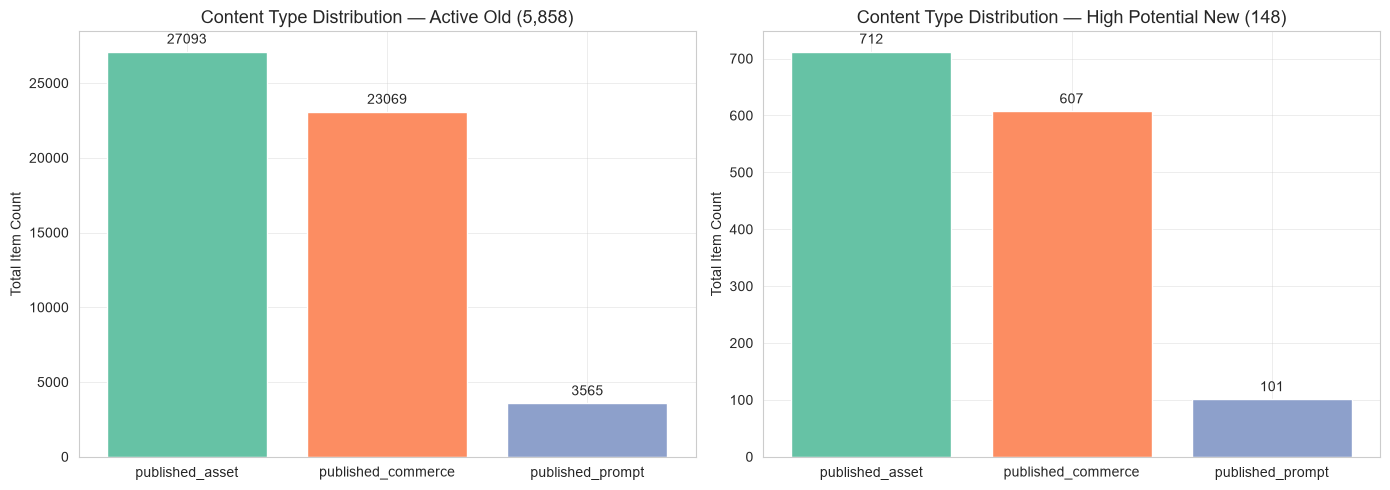

In [10]:
# 9. Content Type 偏好分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (seg, title) in zip(axes, [('active_old', 'Active Old (5,858)'), ('high_potential_new', 'High Potential New (148)')]):
    mask = users_with_stats['user_segment'] == seg
    subset = users_with_stats[mask]
    
    # Aggregate content_type distributions
    ct_agg = Counter()
    for d in subset['content_type_dist']:
        for k, v in d.items():
            ct_agg[k] += v
    
    if ct_agg:
        labels, values = zip(*sorted(ct_agg.items(), key=lambda x: x[1], reverse=True))
        colors = sns.color_palette('Set2', len(labels))
        ax.bar(labels, values, color=colors)
        ax.set_title(f'Content Type Distribution — {title}', fontsize=13)
        ax.set_ylabel('Total Item Count')
        for i, v in enumerate(values):
            ax.text(i, v + max(values)*0.02, str(v), ha='center', fontsize=10)

fig.tight_layout()
plt.show()

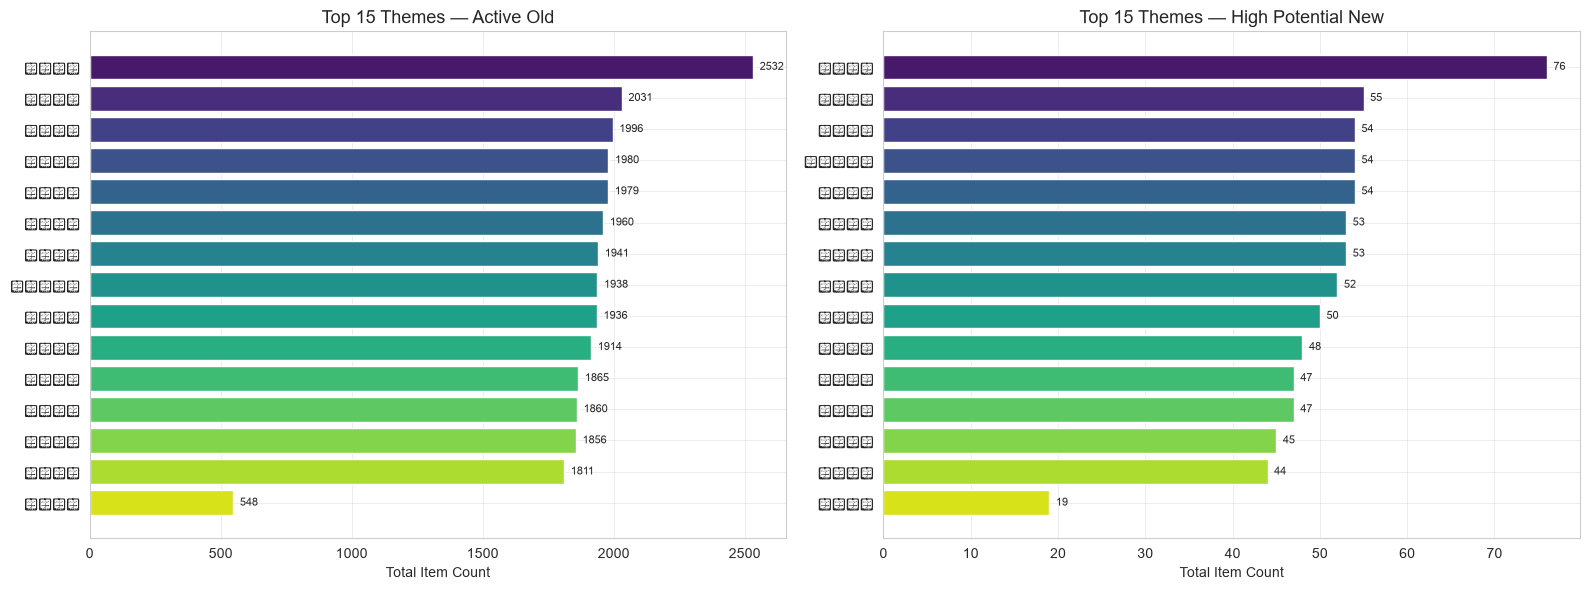

In [11]:
# 10. Theme 偏好 — Top N themes by user segment
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

TOP_N = 15
for ax, (seg, title) in zip(axes, [('active_old', 'Active Old'), ('high_potential_new', 'High Potential New')]):
    mask = users_with_stats['user_segment'] == seg
    subset = users_with_stats[mask]
    
    theme_agg = Counter()
    for d in subset['theme_dist']:
        for k, v in d.items():
            theme_agg[k] += v
    
    top_themes = theme_agg.most_common(TOP_N)
    labels, values = zip(*top_themes) if top_themes else ([], [])
    colors = sns.color_palette('viridis', len(labels))
    bars = ax.barh(range(len(labels)), values, color=colors)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(f'Top {TOP_N} Themes — {title}', fontsize=13)
    ax.set_xlabel('Total Item Count')
    for i, v in enumerate(values):
        ax.text(v + max(values)*0.01, i, str(v), va='center', fontsize=8)

fig.tight_layout()
plt.show()

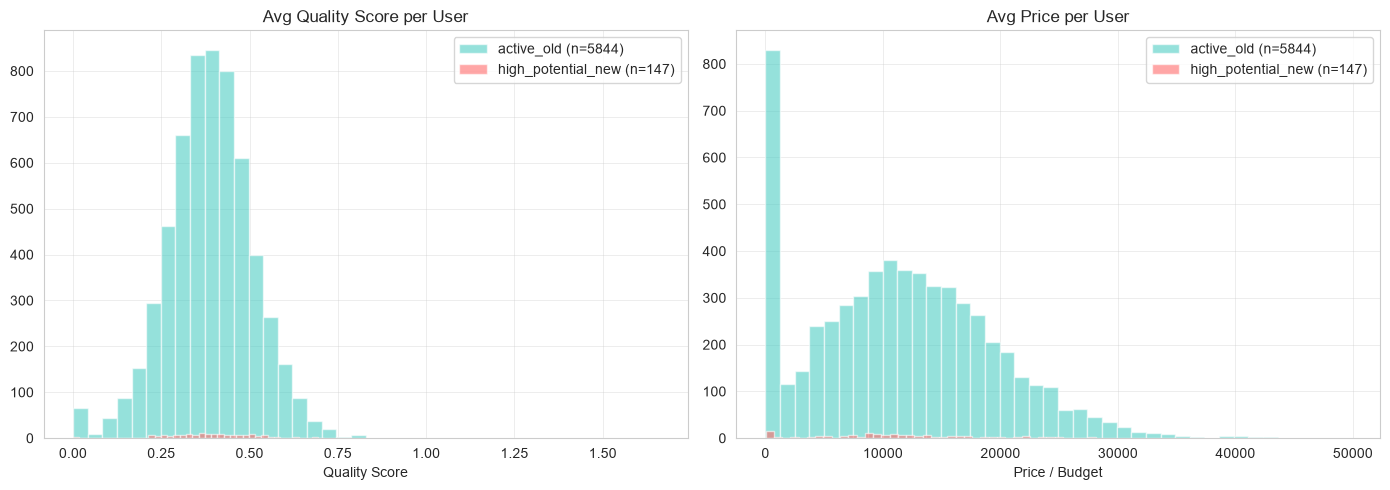

In [12]:
# 11. Quality & Price 分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Quality
for seg, color in [('active_old', '#4ECDC4'), ('high_potential_new', '#FF6B6B')]:
    mask = users_with_stats['user_segment'] == seg
    vals = users_with_stats[mask]['avg_quality'].dropna()
    axes[0].hist(vals, bins=40, alpha=0.6, label=f'{seg} (n={len(vals)})', color=color)
axes[0].set_title('Avg Quality Score per User')
axes[0].set_xlabel('Quality Score')
axes[0].legend()

# Price
for seg, color in [('active_old', '#4ECDC4'), ('high_potential_new', '#FF6B6B')]:
    mask = users_with_stats['user_segment'] == seg
    vals = users_with_stats[mask]['avg_price'].dropna()
    axes[1].hist(vals, bins=40, alpha=0.6, label=f'{seg} (n={len(vals)})', color=color)
axes[1].set_title('Avg Price per User')
axes[1].set_xlabel('Price / Budget')
axes[1].legend()

fig.tight_layout()
plt.show()

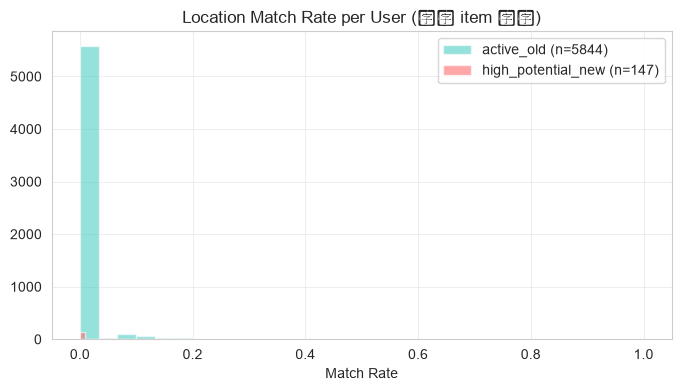

=== Location Match Rate Summary ===
active_old: mean=0.005, median=0.000, users_with_location_match=263/5844
high_potential_new: mean=0.004, median=0.000, users_with_location_match=5/147


In [13]:
# 12. Location 匹配率 — 用户同城 item 占比
fig, ax = plt.subplots(figsize=(8, 4))
for seg, color in [('active_old', '#4ECDC4'), ('high_potential_new', '#FF6B6B')]:
    mask = users_with_stats['user_segment'] == seg
    vals = users_with_stats[mask]['location_match_rate'].dropna()
    ax.hist(vals, bins=30, alpha=0.6, label=f'{seg} (n={len(vals)})', color=color)
ax.set_title('Location Match Rate per User (同城 item 占比)')
ax.set_xlabel('Match Rate')
ax.legend()
plt.show()

print('=== Location Match Rate Summary ===')
for seg in ['active_old', 'high_potential_new']:
    mask = users_with_stats['user_segment'] == seg
    vals = users_with_stats[mask]['location_match_rate'].dropna()
    print(f'{seg}: mean={vals.mean():.3f}, median={vals.median():.3f}, '
          f'users_with_location_match={(vals > 0).sum()}/{len(vals)}')

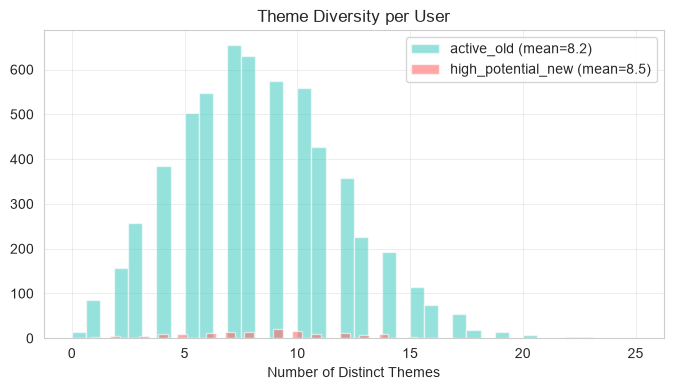

In [14]:
# 13. 每个用户的 theme 多样性（theme_count = 接触了多少种不同的 theme）
fig, ax = plt.subplots(figsize=(8, 4))
for seg, color in [('active_old', '#4ECDC4'), ('high_potential_new', '#FF6B6B')]:
    mask = users_with_stats['user_segment'] == seg
    vals = users_with_stats[mask]['theme_count']
    ax.hist(vals, bins=40, alpha=0.6, label=f'{seg} (mean={vals.mean():.1f})', color=color)
ax.set_title('Theme Diversity per User')
ax.set_xlabel('Number of Distinct Themes')
ax.legend()
plt.show()

In [15]:
# 14. high_potential_new 用户的特殊分析
mask_new = users_with_stats['user_segment'] == 'high_potential_new'
new_users = users_with_stats[mask_new]
print(f'=== High Potential New Users: {len(new_users)} ===')
print(f'Users with 0 items: {(new_users["total_items"]==0).sum()}/{len(new_users)}')
print(f'Users with >= 1 item: {(new_users["total_items"]>=1).sum()}/{len(new_users)}')
print(f'\nTop designations:')
print(new_users['designation'].value_counts().head(10))
print(f'\nTop goodat (前5个样本):')
for i, (_, row) in enumerate(new_users.head(5).iterrows()):
    print(f'  [{i+1}] designation={row["designation"]}, goodat={str(row["goodat"])[:80]}')

=== High Potential New Users: 148 ===
Users with 0 items: 1/148
Users with >= 1 item: 147/148

Top designations:
designation
航拍导演     11
调色师       9
独立摄影师     7
美术指导      7
HR接口人     6
创意总监      4
后期特效师     4
录音师       4
执行导演      3
动画导演      3
Name: count, dtype: int64

Top goodat (前5个样本):
  [1] designation=化妆造型师, goodat=AE动态图形
  [2] designation=虚拟制片人, goodat=剪辑软件精通
  [3] designation=三维动画师, goodat=直播推流
  [4] designation=剧本统筹, goodat=LUT风格化
  [5] designation=音效设计, goodat=延时摄影


In [16]:
# 15. 标签覆盖率统计 — item_full 中有多少 item 能成功 JOIN 到所有维度
print('=== Item Full Coverage ===')
print(f'Total items in item_full: {len(item_full):,}')
print(f'Has content_type: {(~item_full["content_type"].isna()).sum():,}')
print(f'Has theme: {(~item_full["theme"].isna()).sum():,}')
print(f'Has pricing: {(~item_full["pricing"].isna()).sum():,}')
print(f'Has location: {(~item_full["location"].isna()).sum():,}')
print(f'Has tags: {(~item_full["tags"].isna()).sum():,}')
print(f'Has purchase_rate: {(~item_full["purchase_rate"].isna()).sum():,}')
print(f'\nItems with ALL fields: {item_full.dropna(subset=["content_type","theme","pricing","location"]).shape[0]:,}')

=== Item Full Coverage ===
Total items in item_full: 39,000
Has content_type: 39,000
Has theme: 38,659
Has pricing: 39,000
Has location: 39,000
Has tags: 24,447
Has purchase_rate: 9,471

Items with ALL fields: 38,659


In [17]:
from IPython.display import display

# 16. 导出偏好画像摘要
# 对每个用户，整理出可直接用于 Phase A-1 的结构化偏好数据
preference_summary = users_with_stats[[
    'user_id', 'user_segment', 'level', 'rate', 'location', 'designation', 'goodat',
    'total_items', 'n_matched_items', 'theme_count', 'avg_quality', 'avg_price',
    'location_match_rate', 'content_type_dist', 'theme_dist'
]].copy()

print(f'Preference summary shape: {preference_summary.shape}')
print(f'\nSample (active_old):')
display(preference_summary[preference_summary['user_segment']=='active_old'].head(3))
print(f'\nSample (high_potential_new):')
display(preference_summary[preference_summary['user_segment']=='high_potential_new'].head(3))

Preference summary shape: (6006, 15)

Sample (active_old):


,user_id,user_segment,level,rate,location,designation,goodat,total_items,n_matched_items,theme_count,avg_quality,avg_price,location_match_rate,content_type_dist,theme_dist
0,0009a79d-1d76-412e-854e-0cb636eb6687,active_old,6,3.8,鹭门,摄影助理,达芬奇调色,12,12.0,11,0.450566,7599.245833,0.00,"{'published_asset': 6, 'published_commerce': 5...","{'音乐现场': 2, '商业街周年庆狂欢节': 1, '高端私人银行客户沙龙': 1, '..."
1,0012bd9c-afde-4948-8372-a734d1d1bbdf,active_old,7,2.9,唐山市,法律合规顾问,绿幕抠像,15,15.0,12,0.539731,13942.268667,0.00,"{'published_asset': 7, 'published_commerce': 7...","{'古风汉服': 2, '家居装修': 2, '节日民俗': 1, '婚礼现场': 1, '..."
2,0024c0d3-68b5-4284-b8ac-c8804383d15a,active_old,3,3.7,徐州市,独立摄影师,视频剪辑与后期调色,20,20.0,19,0.177586,14067.033500,0.05,"{'published_commerce': 10, 'published_asset': 10}","{'萌宠日常': 2, '珠宝鉴赏私享会': 1, '音乐现场': 1, '跨境电商全球选品..."



Sample (high_potential_new):


,user_id,user_segment,level,rate,location,designation,goodat,total_items,n_matched_items,theme_count,avg_quality,avg_price,location_match_rate,content_type_dist,theme_dist
21,012a43f9-5da6-4db0-966b-3e5701d69a26,high_potential_new,0,3.2,大理市,化妆造型师,AE动态图形,10,10.0,9,0.419727,8628.510000,0.0,"{'published_asset': 6, 'published_commerce': 3...","{'咖啡文化': 2, '电竞比赛': 1, '民俗纪实': 1, '网络安全高峰论坛': ..."
199,097c71a9-0052-47ef-9d68-bd4a481d8a72,high_potential_new,6,4.0,东莞市,虚拟制片人,剪辑软件精通,15,15.0,14,0.365030,16943.923333,0.0,"{'published_commerce': 9, 'published_asset': 5...","{'婚礼现场': 2, '国潮美妆快闪店': 1, '节日民俗': 1, '青年创业路演大赛..."
239,0b3aaa1b-9879-4ec6-990c-6774bacdd190,high_potential_new,10,1.0,太原市,三维动画师,直播推流,10,10.0,10,0.322437,25066.539000,0.0,"{'published_commerce': 9, 'published_prompt': 1}","{'新能源汽车充电站启动仪式': 1, '智能制造基地投产典礼': 1, '5G智慧城市高峰..."


## Phase A-0 结论

运行完上述 cell 后，在这里记录关键发现：

1. ID 数组覆盖率：_____% 的 active_old 用户有 ≥ 1 个可回查 item
2. 匹配率：_____% 的 ID 能在 content_features 中找到（_____% 能在 published_* 的 theme 中找到）
3. Content type 分布差异：_____
4. Theme 集中度：Top 5 themes 占 _____%
5. high_potential_new 的特殊性：_____

### 下一步：Phase A-1
基于上述偏好画像，构建每用户 8 个 Latent Factor。